# Week 2

In Week 1, you implemented a perceptron with a hard step decision.

In this lab, you will build and train a neural network on a dataset named Iris.

Your model will:
1. take the four Iris measurements as input,
2. compute a hidden representation,
3. output class scores for the three Iris species,
4. learn using multi-class cross-entropy loss.

This is the foundation of modern neural network training.

This lab has **two tasks**:
- **Task A: Model from Scratch**
- **Task B: Rebuild the Model with `nn.Module`**

Task A is largely provided for you. Your goal is to study the code carefully and understand how each component works.

Task B is more challenging and requires you to implement a larger portion of the solution yourself. You are expected to apply the concepts learned from Task A and complete the code independently.

**Submission is required for this lab, it worths 3 points. Please ensure that all cells have been run before submitting so the outputs are clearly visible; otherwise, your score may be affected.**

---

### About the Iris Dataset

We will use the Iris dataset. It is a classic machine learning dataset with **150 samples** from **3 flower species**: Setosa, Versicolor, and Virginica.

Each sample has **4 measurements**:
- sepal length
- sepal width
- petal length
- petal width

The task is a multi-class classification problem. Let's first observe the dataset.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()

# Put the data into a table so we can inspect it more easily
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names) # Create a DataFrame with the feature data and column names
iris_df["species"] = [iris.target_names[i] for i in iris.target] # Add a column for the species names based on the target labels

# Print out some basic information about the dataset
print(f"Samples: {iris.data.shape[0]}")
print(f"Features: {iris.data.shape[1]}")
print(f"Classes: {list(iris.target_names)}")

# Display the first few rows of the dataset
print("\nFirst five rows:")
print(iris_df.head().to_string(index=False))

# Display the class distribution
print("\nSamples per class:")
print(iris_df["species"].value_counts())

Samples: 150
Features: 4
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First five rows:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
               5.1               3.5                1.4               0.2  setosa
               4.9               3.0                1.4               0.2  setosa
               4.7               3.2                1.3               0.2  setosa
               4.6               3.1                1.5               0.2  setosa
               5.0               3.6                1.4               0.2  setosa

Samples per class:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Task A: Model from Scratch

In this task, you will load the Iris dataset and turn it into tensors for a **three-class classification** problem.

Goal: complete a model for the 3-class Iris problem. The hidden layer should learn an internal representation, and the output layer should produce 3 class scores (logits). Complete the TODOs.

[HAMI-core Msg(4226:140102843768128:libvgpu.c:839)]: Initializing.....


W1 shape: torch.Size([4, 8])
b1 shape: torch.Size([8])
W2 shape: torch.Size([8, 3])
b2 shape: torch.Size([3])


[HAMI-core Msg(4226:140102843768128:libvgpu.c:855)]: Initialized


Epoch    0 | Loss: 1.0986
Epoch  400 | Loss: 0.1633
Epoch  800 | Loss: 0.0825
Epoch 1200 | Loss: 0.0687
Epoch 1600 | Loss: 0.0626

Check the learned parameter shapes:
W1 shape = (4, 8)
W2 shape = (8, 3)
b1 shape = (8,)
b2 shape = (3,)

Predictions:
Input: [5.099999904632568, 3.5, 1.399999976158142, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [4.900000095367432, 3.0, 1.399999976158142, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [4.699999809265137, 3.200000047683716, 1.2999999523162842, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [4.599999904632568, 3.0999999046325684, 1.5, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [5.0, 3.5999999046325684, 1.399999976158142, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [5.400000095367432, 3.9000000953674316, 1.7000000476837158, 0.4000000059604645] | Target: 0 | Pred: 0
Input: [4.599999904632568, 3.4000000953674316, 1.399999976158142, 0.30000001192092896] | Target: 0 | Pred: 0
Input: [5.0, 3.4000000953674316, 1.5, 0.200000

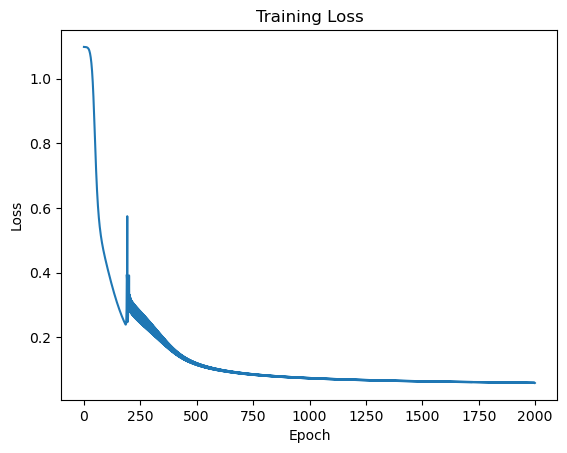

In [2]:
import torch
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# --------------------------------------
# load the dataset
# --------------------------------------
iris = load_iris()
X = torch.tensor(iris.data, dtype=torch.float32)
y = torch.tensor(iris.target, dtype=torch.long) # for CrossEntropyLoss, labels must be integer class ids (dtype=torch.long).

# --------------------------------------
# initialize a MLP classifier
# --------------------------------------
input_size = X.shape[1] # 4 features
hidden_size = 8         # 8 neurons
output_size = 3         # 3 class scores

torch.manual_seed(0)

# TODO: define b1, W2, and b2 with the correct shapes using `torch.randn` and `requires_grad=True`,
# Note that we want to initialize the weights with small random values because large initial weights can lead to unstable training. We can use `torch.randn` multiplied by a small factor (e.g., 0.01) to achieve this.
# Note that the bias terms (b1 and b2) can be initialized to zeros, as they will be updated during training and do not require random initialization.
W1 = torch.nn.Parameter(torch.randn(input_size, hidden_size) * 0.01) # W1 maps input -> hidden
b1 = torch.nn.Parameter(torch.zeros(hidden_size))  # multiple the inputs
W2 = torch.nn.Parameter(torch.randn(hidden_size, output_size) * 0.01)  # multiple the inputs # W2 maps hidden -> output.
b2 = torch.nn.Parameter(torch.zeros(output_size))

print("W1 shape:", W1.shape)  # expected: [4, 8]
print("b1 shape:", b1.shape)  # expected: [8]
print("W2 shape:", W2.shape)  # expected: [8, 3]
print("b2 shape:", b2.shape)  # expected: [3]

# --------------------------------------
# implement the forward pass
# --------------------------------------
# Hint: step 1 -> hidden = sigmoid(XW1 + b1)
# Hint: step 2 -> logits = hiddenW2 + b2
# Hint: return logits (raw scores), not softmax probabilities.
def forward(x):
    # TODO: compute hidden activations with matrix multiply `@` and `torch.sigmoid`.
    hidden = torch.sigmoid(x @ W1 + b1)
    # TODO: compute output logits from the hidden layer.
    logits = hidden @ W2 + b2
    return logits

# --------------------------------------
# set up the loss and optimizer
# --------------------------------------
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD([W1, b1, W2, b2], lr=0.4) # start with SGD; you can test Adam later in optional tasks.

# --------------------------------------
# train the network
# --------------------------------------
# Hint: you may need to experiment with the learning rate and number of epochs to get good results. If the loss is not decreasing, try lowering the learning rate.
epochs = 2000
loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()
    logits = forward(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step() # Update the parameters.

    loss_history.append(loss.item())

    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

# --------------------------------------
# check the learned parameter shapes
# --------------------------------------
print("\nCheck the learned parameter shapes:")
print(f"W1 shape = {tuple(W1.shape)}")
print(f"W2 shape = {tuple(W2.shape)}")
print(f"b1 shape = {tuple(b1.shape)}")
print(f"b2 shape = {tuple(b2.shape)}")

# --------------------------------------
# make predictions
# --------------------------------------
print("\nPredictions:")
with torch.no_grad():
    # TODO: compute logits for the training data.
    logits = forward(X)
    preds = torch.argmax(logits, dim=1) # For multi-class classification, predicted class = argmax(logits).
    for x, target, pred in zip(X, y, preds):
        print(f"Input: {x.tolist()} | Target: {int(target.item())} | Pred: {int(pred.item())}")

# --------------------------------------
# plot the loss curve
# --------------------------------------
# Hint: if loss is very noisy or increases, try lowering learning rate.
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

### Question Set 1: Reflection on the Implementation (Submission is Required)
Investigate the above code, answer the following questions:
1. what is the purpose of `torch.manual_seed()`?

2. Research at least three other loss functions available in PyTorch. For each one:
- State its PyTorch class/function name.

- Describe a suitable use case.


- Explain how it differs from the loss function used in this exercise.

  
3. For the line `loss = criterion(logits, y)`, answer the following:
- What are the inputs to criterion?
- What does the output represent?
- Why do we compare the model outputs (logits) with the true labels (y)?
  
4. What is the difference between:
- logits,
- probabilities,
- predicted labels?
  
Give an example showing how one can be transformed into another.

---


### TODO: Answers of Question Set 1

Please write your answers below. Be clear and concise.
1. `torch.manual_seed()` PyTorch function that locks in a fixed seed for the random number generator every time you run the code. This makes sure that the initial weights (W1 and W2) are exactly the same on every single run. By keeping the starting point consistent, the training results become completely reproducible. This means per training round, you won't get different results just by random chance, which makes it much easier to debug the code and fairly compare different training experiments.
   
2. PyTorch class/function name:

Loss function 1: L1Loss (torch.nn.L1Loss()). It measures computes the average absolute difference between predicted and actual values. Suitable for regression problems where you need to predict a continuous numerical value, like predicting house prices or tracking daily temperatures, especially when the data has outliers. This loss fucntion would not be suitable for this classification task because it works with continuous numbers instead of class probabilities.

Loss function 2: MSELoss (torch.nn.MSELoss(), is a regression task which computes the average of the squared differences between predictions and targets values. It heavily penalise large errors, making it highly sensitive to outliers. MSELoss is generally not a good choice for classification tasks because it assumes errors follow a continuous Gaussian distribution, which can lead to incredibly slow training when paired with classification outputs.

Loss function 3: NLLLoss (Negative Log Likelihood Loss) (torch.nn.NLLLoss) measures the predicted distribution (target log distribution). It uses LogSoftmax output. This can be used Multi-class classification task with more than one label (i.e., cat vs dog vs bird) and can be used as an alternative to CrossEntropyLoss because they achieve the same results. However, NLLLoss requires an additional step of applying LogSoftmax to the output combine with NNLLLoss and CrossEntropyLoss handles this automatically in a single step for you. Example of the code:

# Step 1: Apply LogSoftmax
log_softmax = torch.nn.LogSoftmax(dim=1)
log_probs = log_softmax(logits)

# Step 2: Apply NLLLoss
criterion = torch.nn.NLLLoss()
loss = criterion(log_probs, y)

3. loss = criterion(logits, y): The inputs are logits (the raw, unnormalised prediction scores coming straight from the model) and y (the true target labels). The output is a single number ( a scalar) that represents the total error or "loss" for that specific round of predictions.

We need to compare model outputs with true labels because the model needs clear feedback to learn and get better. Because the weights start out completely random, the model's initial predictions (logits) will be way off. By comparing these predictions to the true labels (y), the loss function calculates a concrete error score.Gradient descent uses this error score to figure out exactly how to adjust the weights and biases to make the model smarter.

The model makes predictions (logits). By comparing these predictions to the true labels (y), the loss function calculates an error. Then gradient descent uses this error to adjust weights, biases, and update the learning rate. This iterative process repeats until the model consistently highly accurate, and making it ready for the evaluation stage on unseen data.

4. The difference between:

Logits: Logits are the raw, unnormalised scores that come directly out of the model's final layer before any squashing function is applied. They are calculated as logits = hidden @ W2 + b2. Logits can be any positive or negative number, but, and do not add up to 1.

Code example: 
def forward(x):
    hidden = torch.sigmoid(x @ W1 + b1)
    logits = hidden @ W2 + b2
    return logits

Probabilities: Probabilities are logits transformed by the softmax function. They represent the likelihood of each class, sum to 1, and are all between 0 and 1. The formula is: probability = softmax(logits) = e^logits / sum(e^logits)
Example: softmax([2.0, 0.5, -1.0]) = [0.66, 0.24, 0.10]


Predicted labels: Predicted labels are the final class decisions which are obtains the argmax of probabilities (or directly from logits). For example, apply the Softmax function to turn those scores into percentages: softmax([2.0, 0.5, -1.0]) ---> [0.66, 0.24, 0.10]. This means the model is 66% sure the flower belongs to Class 0.



### Question Set 2: Reflection on the Training Process (submission is required)
We implemented the training processing using the code below:
```python
optimizer.zero_grad()  
logits = forward(X)    
loss = criterion(logits, y)  
loss.backward()        
optimizer.step()       
```
For each line in the training loop:
- Explain what the line does.
- Explain why it is needed.
- Explain what would happen if the line were removed or executed in the wrong order.
Use reliable sources (e.g., PyTorch documentation, tutorials, or textbooks) to support your explanations.

Also answering the following questions:
1. Why do trainable model parameters typically have `requires_grad=True`?
2. What exactly is being updated when optimizer.step() is called?
3. Why do we call `optimizer.zero_grad()` before `loss.backward()`?
4. Why are `logits` (raw scores) passed to `criterion` instead of predicted labels?
5. What information does `loss.backward()` compute, and where is it stored?
6. Why must `optimizer.step()` happen after gradients are computed?
7. What would happen if loss.backward() were called twice without first calling optimizer.zero_grad()?



### TODO: Answers of Question Set 2

Please write your answers below. Be clear and concise.
Code:
optimizer.zero_grad()  
logits = forward(X)    
loss = criterion(logits, y)  
loss.backward()        
optimizer.step()  


Code: optimizer.zero_grad()

Explanation: Sets gradients of all model parameters to zero before starting to do backprogagtion.

PyTorch accumulates gradients by default (adds new gradients to existing ones). Without resetting, gradients from previous iterations would keep adding up, causing incorrect updates. Using `zero_grad()` ensures each batch starts with fresh gradients.

If `zero_grad()` is removed, then gradients accumulate across iterations, growing larger each step. This leads to unstable training, and the model failing to learn properly. If called AFTER `loss.backward()`, gradients would be zeroed before the optimizer uses them, resulting in no parameter updates.

code: logits = forward(X)  

It performs the forward pass by passing the input features (X) through the network layers to calculate the raw, unnormalised output scores, known as logits.

 The model must generate a prediction before you can figure out how wrong it was. These raw logits reflect the network's current state based on its current weights and biases.

If removed, there are no predictions to evaluate, throwing an error immediately. If executed out of order (e.g., after the loss function), the code breaks because the loss calculation requires these logits as a direct input parameter.



Code: loss = criterion(logits, y)

Explanation: Calculates the error between your model's predictions (logits) and the ground-truth targets (y). 

Why it is needed: The loss value acts as a single scalar metric that quantifies how well or poorly the model is performing. It serves as the starting point for the backward pass to calculate gradients.

Without this line, you have no quantitative metric of error. Because you cannot differentiate a missing loss value, backpropagation cannot happen, meaning you cannot update the model's parameters.

Code: loss.backward()

Explanation: triggers PyTorch’s autograd engine to perform backpropagation. It computes the derivative (gradient) of the loss with respect to every model parameter that has requires_grad=True.

This line calculates the steepness and direction (the gradient slope) showing exactly how changing each weight and bias will affect the overall loss. If removed, no gradients are calculated. The parameters' .grad properties remain unpopulated, leaving optimizer.step() with no data to act upon, which stalls all model learning.

Code: optimizer.step() 

Explanation: After loss.backward() computes the gradient of the current tensor, this triggers optimizer.step() with the purpose to perform a single optimization step to update parameters according to the chosen optimization algorithm (i.e., gradient descent).

The connection between loss.backward() and optimizer.step():
- loss.backward() calculates the slope (gradient) to understand how to update parameters
- optimizer.step() performs the actual movement toward a lower loss value

If removed, the model will calculate its mistakes but never actually correct them, leaving the network frozen with its initial random weights.

Additional answers (corresponds to the listed questions above)

1. (requires_grad=True) ells PyTorch’s autograd engine to build a computational graph tracking every mathematical operation involving that tensor. This history tracking is mandatory because, without it, PyTorch cannot compute the derivatives needed during the backward pass to update that specific parameter.

2. (optimizer.step()is when a model's trainable parameters of the weights matrix (W) and the bias vector (b) across all layers specified within the optimizer.setup() are updated.

3. If optimizer.zero_grad() before loss.backward() as part of the process is because loss.backward() calculates and automatically adds newly computed gradients directly to whatever values are currently stored in the .grad attributes. You must clear out the old data using zero_grad() first so that the newly calculated values accurately represent only the current batch's performance.

4. PyTorch accumulates the gradients by default. If this is remove then the zero_grad(), gradients from previous iterations will add to current gradients instead of replacing them. This would cause incorrect updates because the optimizer would use accumulated gradients from multiple previous batches/epochs.

5. loss.backward() It computes the partial derivatives of the loss with respect to each parameter with respect to every trainable parameter (W1, b1, W2, b2). The gradients are stored in the .grad attribute of each respective parameter tensor.

6. The mathematical update rule of an optimiser relies directly on gradients. If the update happen when the weights before running loss.backward(), the .grad fields will either be empty or contain outdated information from a prior loop step.

7. loss.backward() were called twice without first calling optimizer.zero_grad() means the gradients from both backward passes would accumulate and add together within the .grad attributes. When optimizer.step() is eventually called, it will execute an excessively large parameter adjustment based on the combined total, throwing off the optimisation track and likely causing training to become highly unstable.

### TODO: Workflow (Submission is Required)
Fill in the blanks below to describe how the Task A code is structured:

The Task A code follows a standard PyTorch training workflow.

First, we load the dataset and convert it into Tensors format.
Next, we initialize model parameters using random initialization.
Then we define the forward function to compute predictions from the model.
After that, we set up the loss function and the optimiser used for updating parameters.

During training, we repeat a training loop where we:
- clear gradients using optimizer.zero_grad(),
- compute predictions using forward(X),
- calculate the loss,
- compute gradients using loss.backward(),
- and update parameters using optimizer.step().

After training, we evaluate the model by:
- turning off gradient tracking using with torch.no_grad(),
- computing model outputs on the data,
- and selecting predicted classes using torch.argmax().

Finally, we compare the predicted labels with the target labels to measure performance.

## Task B: Rebuild the Model with `nn.Module`

Now you will rewrite the same neural network using PyTorch's module API.

This second big task has the same learning goal as Task A, but now you will build the model in the standard PyTorch style.

Complete the TODOs. Tutorial code an be found in the Pytorch documentation for building a simple feedforward neural network: https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html

X_tensor_demo shape: torch.Size([150, 4])
y_tensor_demo shape: torch.Size([150])
Epoch    0 | Loss: 1.1258
Epoch  400 | Loss: 0.0401
Epoch  800 | Loss: 0.0352
Epoch 1200 | Loss: 0.0274
Epoch 1600 | Loss: 0.0135

Inspect the learned parameters:
tensor([[  2.2952,  -1.5633,   2.7803, -10.0733],
        [  2.7162,  -0.3961,  -4.3501,  -2.2338],
        [  0.4478,   0.8043,   1.2027, -11.6109],
        [  3.0252, -11.1295,   2.9967,   1.8451],
        [  0.2157,   0.4283,   3.6222,   2.1009],
        [  0.5841,   1.7260,  -2.5831,  -2.9206],
        [  0.0361,   2.1632,  -2.0386,  -2.2021],
        [  0.8382,   1.8533,  -3.1274,  -3.2146]])

Predictions from module model:
Input: [5.099999904632568, 3.5, 1.399999976158142, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [4.900000095367432, 3.0, 1.399999976158142, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [4.699999809265137, 3.200000047683716, 1.2999999523162842, 0.20000000298023224] | Target: 0 | Pred: 0
Input: [4.599999904632568,

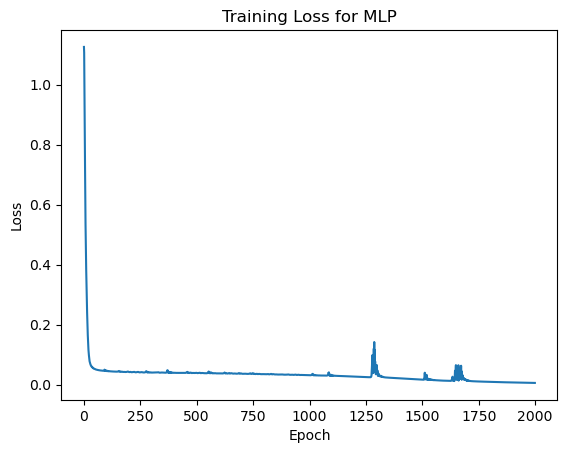

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# --------------------------------------
# load the dataset
# --------------------------------------
iris = load_iris()
X_tensor_demo = torch.tensor(iris.data, dtype=torch.float32)
y_tensor_demo = torch.tensor(iris.target, dtype=torch.long)

# Quick checks
print("X_tensor_demo shape:", X_tensor_demo.shape)
print("y_tensor_demo shape:", y_tensor_demo.shape)

# --------------------------------------
# define the model class and the forward pass
# --------------------------------------
# Hint: `__init__` defines layers, `forward` defines data flow.
# Hint: use `nn.Linear` for layers and `nn.Sigmoid` for hidden activation.
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: define hidden layer, to match with Task A, hidden layer should have 8 units and take input of size 4.
        self.hidden = nn.Linear(4, 8)
        # TODO: define output layer, output layer should produce logits for 3 classes.
        self.output = nn.Linear(8, 3)
        # TODO: define activation function, for hidden layer we will use sigmoid activation function.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # TODO: implement forward pass in 3 steps:
        x = self.hidden(x)  #hidden_linear
        x = self.sigmoid(x) # activation
        x = self.output(x)  #output
        return x           # logits

# --------------------------------------
# create model, loss, and optimizer
# --------------------------------------
# Hint: use the same loss and optimizer type as Task A first.
# TODO: instantiate model
model = MLP ()
# TODO: define criterion
criterion = torch.nn.CrossEntropyLoss()
# TODO: define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.12)

# --------------------------------------
# train the module
# --------------------------------------
# Hint: this loop should look almost identical to Task A.
epochs = 2000
loss_history_tensor = []

for epoch in range(epochs):
    # TODO: forward pass to get logits
    logits = logits = model(X_tensor_demo)
    # TODO: compute loss
    loss = criterion(logits, y_tensor_demo)
    # TODO: store loss value in loss_history_tensor
    loss_history_tensor.append(loss.item())
    # TODO: zero gradients
    optimizer.zero_grad()
    # TODO: backward pass
    loss.backward()
    # TODO: optimizer step
    optimizer.step()

    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

print("\nInspect the learned parameters:")
# TODO: print hidden and output weights/biases using `.detach()`
print(model.hidden.weight.detach())

# --------------------------------------
# make predictions with the module
# --------------------------------------
# Hint: compare a few predictions manually to build intuition.
print("\nPredictions from module model:")
with torch.no_grad():
    # TODO: get logits from model
    logits = model(X_tensor_demo)
    # TODO: convert logits to predicted classes using argmax
    preds = torch.argmax(logits, dim=1)
    for x, target, pred in zip(X_tensor_demo, y_tensor_demo, preds):
        print(f"Input: {x.tolist()} | Target: {int(target.item())} | Pred: {int(pred.item())}")

# --------------------------------------
# plot the loss curve
# --------------------------------------
# Hint: compare this curve against Task A to check consistency.
plt.plot(loss_history_tensor)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss for MLP")
plt.show()

### TODO: Reflection and Comparison (submission is required)

Fill-in the blanks below for a comparison between the two implementations:

1. In Task A, model parameters are created manually using torch.randn() and torch.zeros(), while in Task B they are created automatically inside nn.Linear.
2. In Task B, the model architecture is defined using classes (nn.Module), whereas in Task A it is defined by explicitly writing operations step-by-step.
3. In Task A, weights and biases are stored as tensor variables, while in Task B they are stored inside an nn.Module object.
4. The forward pass in Task A is written explicitly using operations like matrix multiplication, while in Task B it is handled by the forward method.
5. The mathematical computation in both Task A and Task B is same, but the implementation level is manual vs abstracted.
6. In Task A, we manually compute gradients using loss.backward(), while in Task B this is handled automatically by PyTorch's autograd.
7. The parameter update step in Task A is done manually, but in Task B it is performed using optimizer.step() .
8. The operation nn.Linear in Task B internally performs the same computation as x @ W + b in Task A.
9. Task B has a shorter training loop because PyTorch automates gradient computation and parameter management.
10. The main advantage of Task A is higher control, while the main advantage of Task B is efficient.


### Optional Tasks (submission is NOT required)

- change the hidden size and see what happens,
- try `optim.Adam` instead of `optim.SGD`,
- add an accuracy calculation after training,
- compare the loss curve for different learning rates.
- create mini-batches for Iris and train the model using them. Then compare the training behavior with full-batch learning.